# Part A

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
flights = pd.read_csv("flight-on-time-performance.csv")


In [2]:
flights.head()

,_id,Route,Departing_Port,Arriving_Port,Airline,Month,Sectors_Scheduled,Sectors_Flown,Cancellations,Departures_On_Time,Arrivals_On_Time,Departures_Delayed,Arrivals_Delayed,Year,Month_Num
0,932,Sydney-Darwin,Sydney,Darwin,Qantas,Apr-04,30.0,30,0.0,29.0,27.0,1.0,3.0,2004,4
1,1072,Townsville-Sydney,Townsville,Sydney,Virgin Australia,Apr-04,30.0,30,0.0,26.0,27.0,4.0,3.0,2004,4
2,1071,Townsville-Brisbane,Townsville,Brisbane,Virgin Australia,Apr-04,81.0,80,1.0,72.0,74.0,8.0,6.0,2004,4
3,1070,Sydney-Townsville,Sydney,Townsville,Virgin Australia,Apr-04,30.0,30,0.0,27.0,25.0,3.0,5.0,2004,4
4,1069,Sydney-Sunshine Coast,Sydney,Sunshine Coast,Virgin Australia,Apr-04,30.0,30,0.0,27.0,27.0,3.0,3.0,2004,4


In [3]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112957 entries, 0 to 112956
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   _id                 112957 non-null  int64  
 1   Route               112957 non-null  object 
 2   Departing_Port      112957 non-null  object 
 3   Arriving_Port       112957 non-null  object 
 4   Airline             112957 non-null  object 
 5   Month               112957 non-null  object 
 6   Sectors_Scheduled   112957 non-null  float64
 7   Sectors_Flown       112957 non-null  int64  
 8   Cancellations       112641 non-null  float64
 9   Departures_On_Time  112957 non-null  float64
 10  Arrivals_On_Time    112957 non-null  float64
 11  Departures_Delayed  112952 non-null  float64
 12  Arrivals_Delayed    112957 non-null  float64
 13  Year                112957 non-null  int64  
 14  Month_Num           112957 non-null  int64  
dtypes: float64(6), int64(4), object(5)

In [4]:
flights.columns

Index(['_id', 'Route', 'Departing_Port', 'Arriving_Port', 'Airline', 'Month',
       'Sectors_Scheduled', 'Sectors_Flown', 'Cancellations',
       'Departures_On_Time', 'Arrivals_On_Time', 'Departures_Delayed',
       'Arrivals_Delayed', 'Year', 'Month_Num'],
      dtype='object')

In [6]:
print(min(flights['Year']), max(flights['Year']))

2004 2025


In [78]:
print(max(flights['Month_Num'][flights['Year'] == 2004]))

12


In [7]:
flights['Airline'].unique()

array(['Qantas', 'Virgin Australia', 'Skywest', 'Regional Express',
       'QantasLink', 'All Airlines', 'Jetstar', 'Macair',
       'Tigerair Australia', 'Virgin Australia - ATR/F100 Operations',
       'Virgin Australia Regional Airlines', 'Rex Airlines', 'Hinterland',
       'Skytrans', 'virgin Australia', 'Bonza', 'Ozjet', 'MacAir'],
      dtype=object)

In [8]:
all_airlines = flights[flights["Airline"] == "All Airlines"]

In [9]:
yearly_total = all_airlines.groupby("Year")["Sectors_Scheduled"].sum().reset_index()

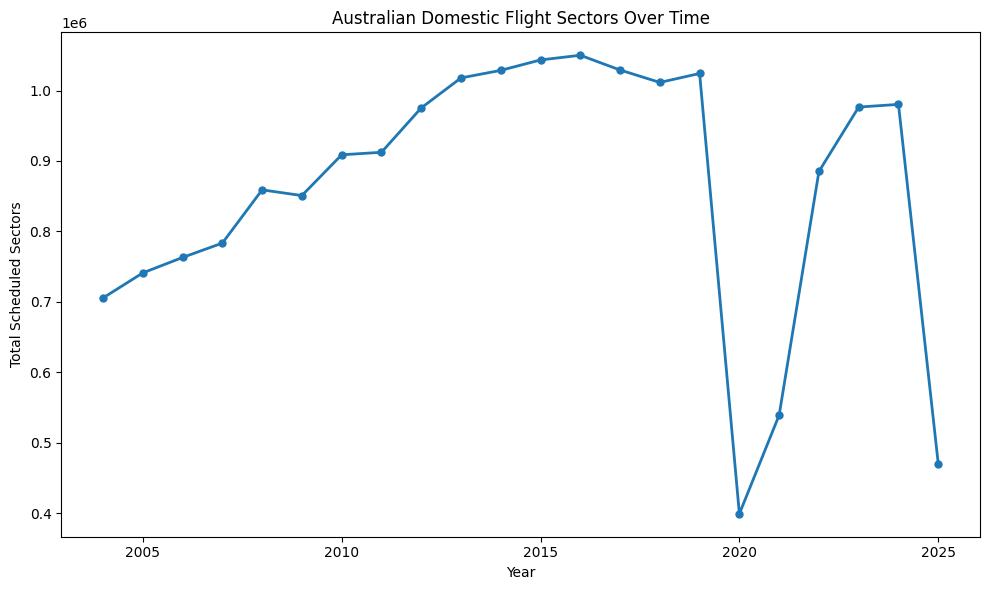

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(yearly_total["Year"], yearly_total["Sectors_Scheduled"], marker="o", linewidth=2, markersize=5)
ax.set_xlabel("Year")
ax.set_ylabel("Total Scheduled Sectors")
ax.set_title("Australian Domestic Flight Sectors Over Time")
fig.tight_layout()

In [12]:
all_airlines["Calculated_Total"] = all_airlines["Arrivals_On_Time"] + all_airlines["Arrivals_Delayed"] + all_airlines["Cancellations"]

C:\Users\ryanw\AppData\Local\Temp\ipykernel_3652\1069484589.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_airlines["Calculated_Total"] = all_airlines["Arrivals_On_Time"] + all_airlines["Arrivals_Delayed"] + all_airlines["Cancellations"]


In [13]:
mismatch = all_airlines[all_airlines["Sectors_Scheduled"] != all_airlines["Calculated_Total"]]
print(f"Found {len(mismatch)} mismatches")
print(mismatch[["Year", "Month", "Sectors_Scheduled", "Calculated_Total"]])

Found 39 mismatches
        Year   Month  Sectors_Scheduled  Calculated_Total
265     2004  Apr-04            32782.0      32788.000000
9601    2004  Aug-04            36287.0      36274.000000
9615    2004  Aug-04              101.0        102.000000
9626    2004  Aug-04               70.0         71.000000
9632    2004  Aug-04               62.0         61.000000
9633    2004  Aug-04              429.0        430.000000
9634    2004  Aug-04              128.0        131.000000
9635    2004  Aug-04              223.0        228.000000
18774   2004  Dec-04              356.0        357.000000
28308   2004  Feb-04            31181.0      31151.000000
28333   2004  Feb-04              222.0        223.000000
28339   2004  Feb-04              109.0        107.000000
28358   2004  Feb-04               77.0         76.000000
28359   2004  Feb-04              108.0        107.000000
28368   2004  Feb-04               58.0         59.000000
28372   2004  Feb-04              804.0        805.0

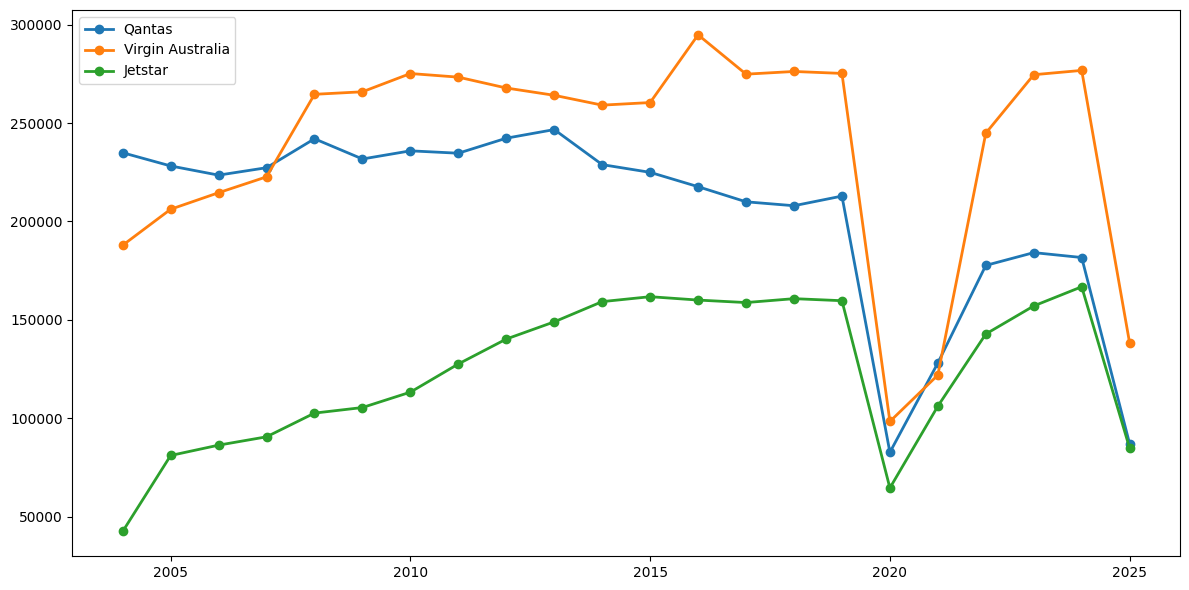

In [14]:
airlines_to_plot = ["Qantas", "Virgin Australia", "Jetstar"]

fig, ax = plt.subplots(figsize=(12, 6))

for airline in airlines_to_plot:
    airline_data = flights[flights["Airline"] == airline]
    yearly = airline_data.groupby("Year")["Sectors_Scheduled"].sum().reset_index()
    ax.plot(yearly["Year"], yearly["Sectors_Scheduled"], marker="o", linewidth=2, label=airline)
ax.legend()
fig.tight_layout()

# Part B

In [15]:
flights["Airline_Clean"] = flights["Airline"].str.title()
flights["Airline_Clean"].unique()

array(['Qantas', 'Virgin Australia', 'Skywest', 'Regional Express',
       'Qantaslink', 'All Airlines', 'Jetstar', 'Macair',
       'Tigerair Australia', 'Virgin Australia - Atr/F100 Operations',
       'Virgin Australia Regional Airlines', 'Rex Airlines', 'Hinterland',
       'Skytrans', 'Bonza', 'Ozjet'], dtype=object)

In [16]:
flights["Airline_Clean"] = flights["Airline_Clean"].replace({
    "Macair": "MacAir", "Regional Express": "Rex Airlines"
})


In [18]:
flights_per_airline = flights[flights["Airline_Clean"] != "All Airlines"].copy()

print(len(flights_per_airline), len(flights))

83910 112957


In [19]:
avg_per_airline = flights_per_airline.groupby("Airline_Clean")["Sectors_Scheduled"].mean().reset_index()
avg_per_airline = avg_per_airline.sort_values("Sectors_Scheduled", ascending=False)

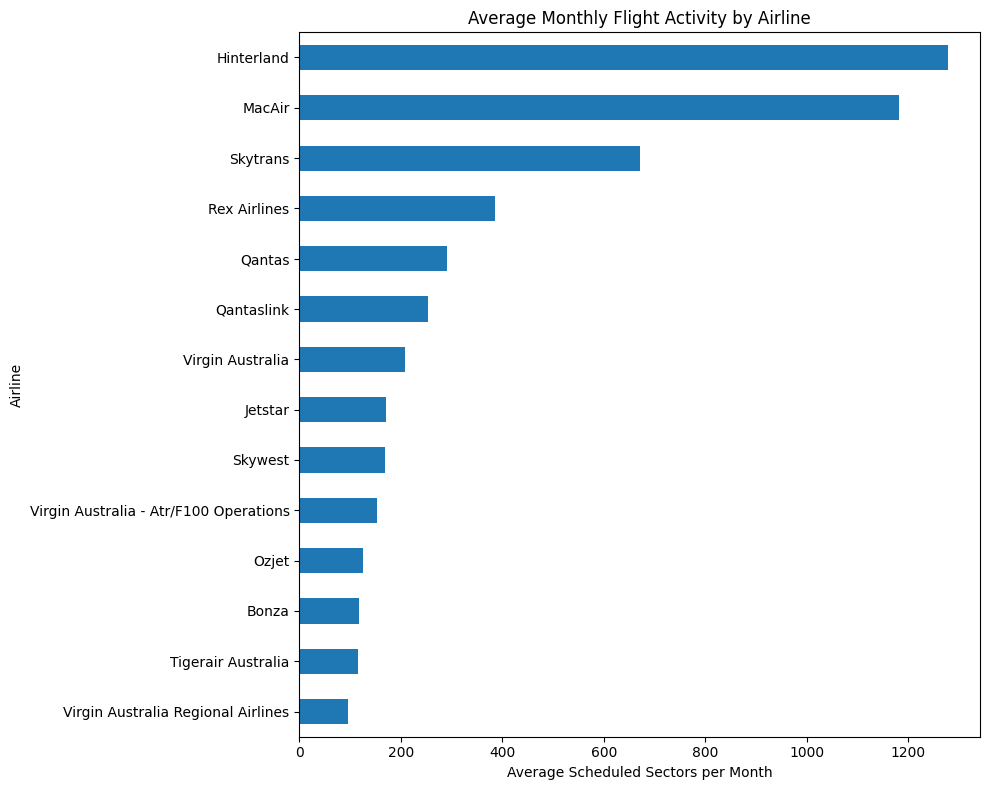

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
avg_per_airline.plot.barh(x="Airline_Clean", y="Sectors_Scheduled", ax=ax, legend=False)
ax.set_xlabel("Average Scheduled Sectors per Month")
ax.set_ylabel("Airline")
ax.set_title("Average Monthly Flight Activity by Airline")
ax.invert_yaxis()
fig.tight_layout()


In [24]:
total_per_airline = flights_per_airline.groupby("Airline_Clean")["Sectors_Scheduled"].sum().reset_index()
total_per_airline = total_per_airline.sort_values("Sectors_Scheduled", ascending=False)

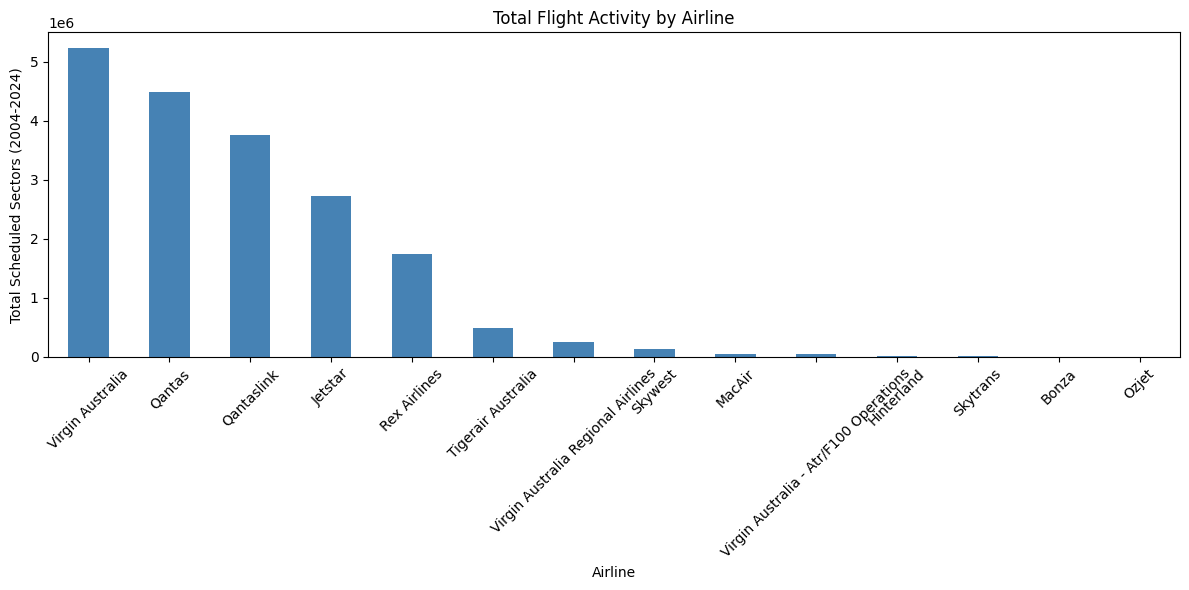

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))
total_per_airline.plot.bar(x="Airline_Clean", y="Sectors_Scheduled", ax=ax, legend=False, color="steelblue")
ax.set_xlabel("Airline")
ax.set_ylabel("Total Scheduled Sectors (2004-2024)")
ax.set_title("Total Flight Activity by Airline")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

# Part C

In [27]:
airline_delays = flights_per_airline.groupby("Airline_Clean").agg({"Departures_Delayed": "sum", 
                                                                   "Arrivals_Delayed": "sum", "Sectors_Flown": "sum"}).reset_index()
airline_delays["Departure_Delay_Rate"] = (airline_delays["Departures_Delayed"] / airline_delays["Sectors_Flown"])
airline_delays["Arrival_Delay_Rate"] = (airline_delays["Arrivals_Delayed"] / airline_delays["Sectors_Flown"])


In [28]:
airline_delays.head()

,Airline_Clean,Departures_Delayed,Arrivals_Delayed,Sectors_Flown,Departure_Delay_Rate,Arrival_Delay_Rate
0,Bonza,1088.0,1044.0,3881,0.280340,0.269003
1,Hinterland,1673.0,2553.0,20194,0.082846,0.126424
2,Jetstar,648681.0,612116.0,2638539,0.245849,0.231991
3,MacAir,8609.0,8740.0,48977,0.175776,0.178451
4,Ozjet,58.0,130.0,1126,0.051510,0.115453


In [42]:
import matplotlib.pyplot as plt
cmap = plt.cm.tab20
airlines_list = airline_delays["Airline_Clean"].unique()
palette = {airline: cmap(i) for i, airline in enumerate(airlines_list)}

In [43]:
airline_delays["Color"] = airline_delays["Airline_Clean"].map(palette)


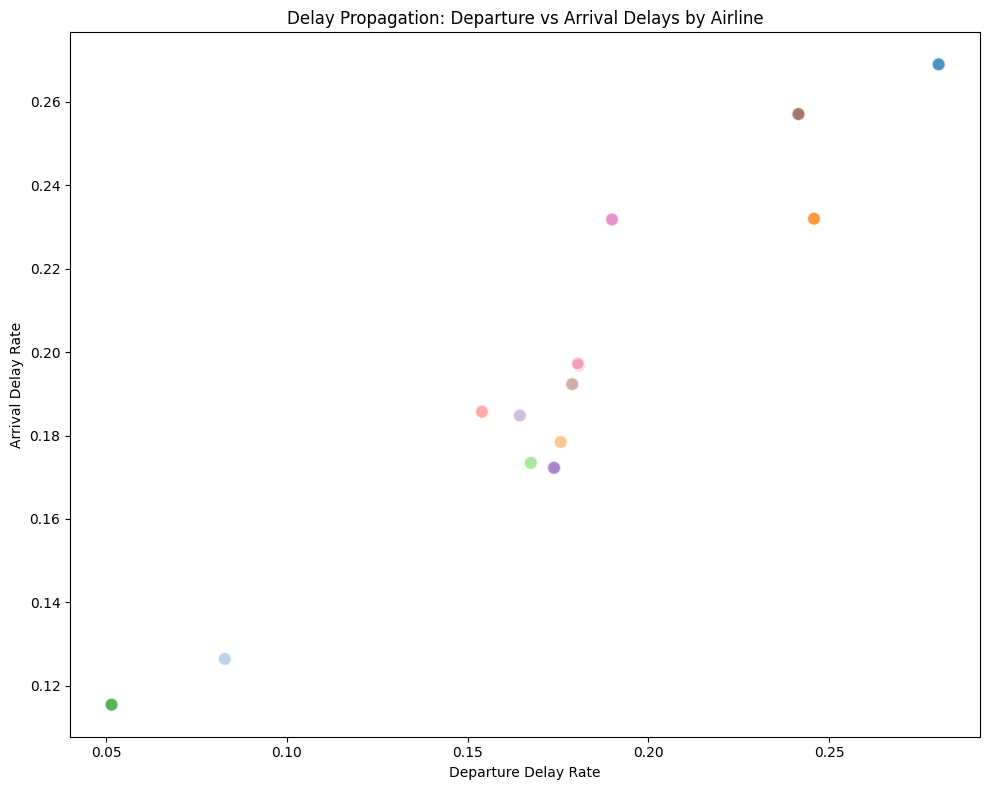

In [51]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(airline_delays["Departure_Delay_Rate"], airline_delays["Arrival_Delay_Rate"], 
           c=airline_delays["Color"], s=100, edgecolor="white", linewidth=1.5, alpha=0.8)
ax.set_xlabel("Departure Delay Rate")
ax.set_ylabel("Arrival Delay Rate")
ax.set_title("Delay Propagation: Departure vs Arrival Delays by Airline")
fig.tight_layout()


In [52]:
from sklearn.linear_model import LinearRegression
X = airline_delays[["Departure_Delay_Rate"]].values
y = airline_delays["Arrival_Delay_Rate"].values
model = LinearRegression()
model.fit(X, y)
# Generate points for the trendline
x_range = np.linspace(X.min(), X.max(), 100)
y_pred = model.predict(x_range.reshape(-1, 1))

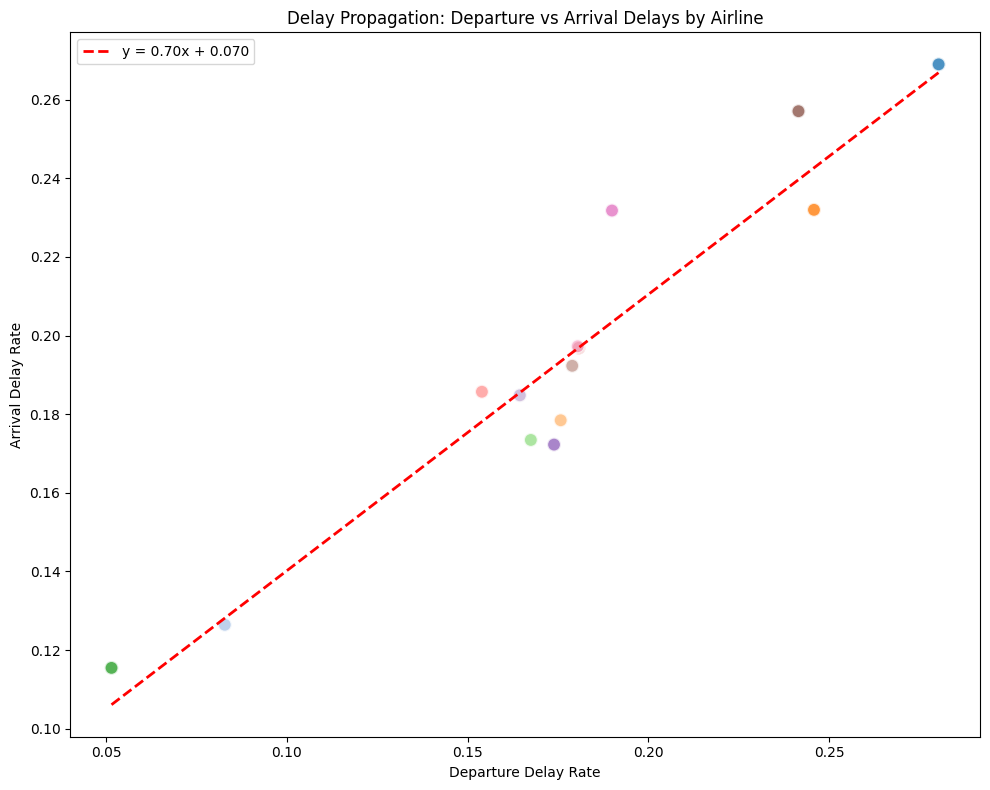

In [53]:
ax.plot(x_range, y_pred, color="red", linewidth=2, linestyle="--", label=f"y = {model.coef_[0]:.2f}x + {model.intercept_:.3f}")
ax.legend()
fig

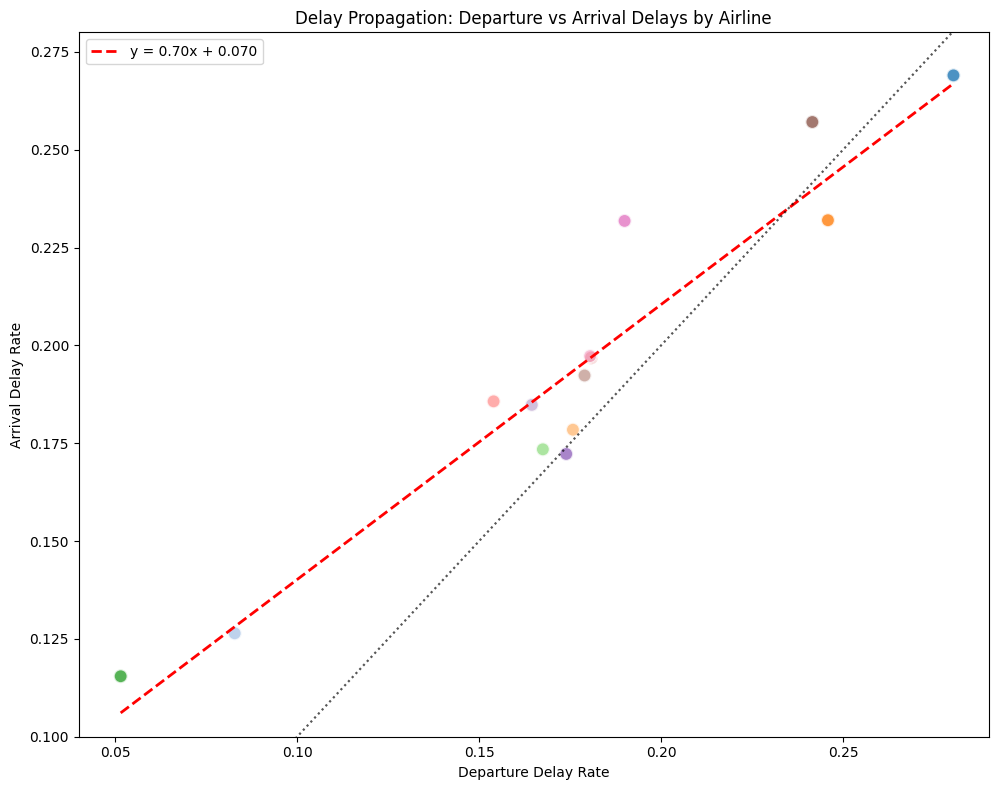

In [57]:
ax.plot([0, 0.5], [0, 0.5], 'k:', alpha=0.3)
ax.set(xlim=(0.04, 0.29), ylim=(0.1, 0.28))
fig

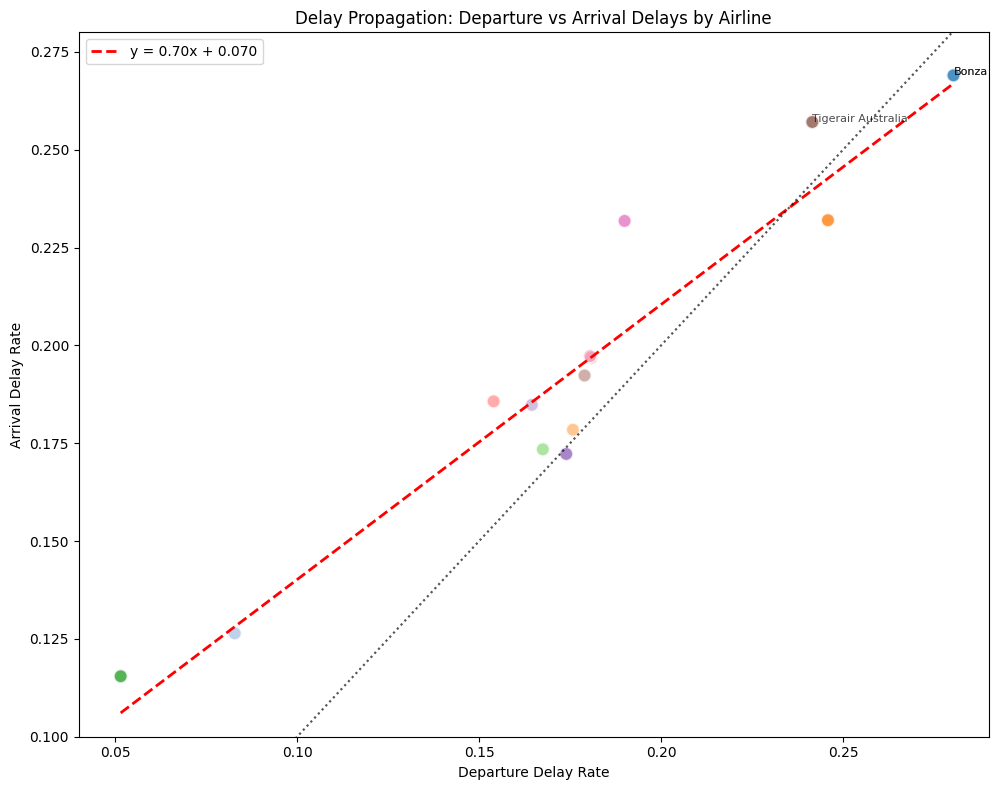

In [60]:
for idx, row in airline_delays.iterrows():
    if (row["Departure_Delay_Rate"] > 0.25 or row["Arrival_Delay_Rate"] > 0.25):
        ax.annotate(row["Airline_Clean"], (row["Departure_Delay_Rate"], row["Arrival_Delay_Rate"]), fontsize=8, alpha=0.7)
fig

# Stretch Goals

In [61]:
all_airlines = flights[flights["Airline"] == "All Airlines"]

airline_delays_years = all_airlines.groupby("Year").agg({"Departures_Delayed": "sum",
                                                                   "Arrivals_Delayed": "sum",
                                                                   "Sectors_Flown": "sum"}
                                                                 ).reset_index()

airline_delays_years["Departure_Delay_Rate"] = airline_delays_years["Departures_Delayed"] / airline_delays_years["Sectors_Flown"]
airline_delays_years["Arrival_Delay_Rate"] = airline_delays_years["Arrivals_Delayed"] / airline_delays_years["Sectors_Flown"]

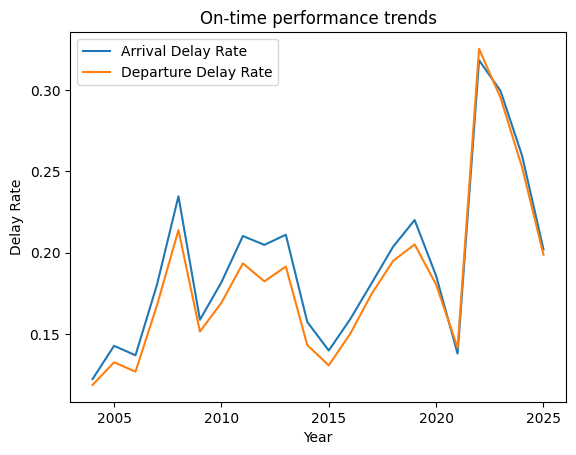

In [62]:
fig, ax = plt.subplots()

ax.plot(airline_delays_years["Year"], airline_delays_years["Arrival_Delay_Rate"], label='Arrival Delay Rate')
ax.plot(airline_delays_years["Year"], airline_delays_years["Departure_Delay_Rate"], label='Departure Delay Rate')

ax.set(xlabel='Year', ylabel='Delay Rate', title='On-time performance trends')
ax.legend()

[Text(0, 0.5, 'Average proportion of on-time flights'), Text(0.5, 0, 'Year')]

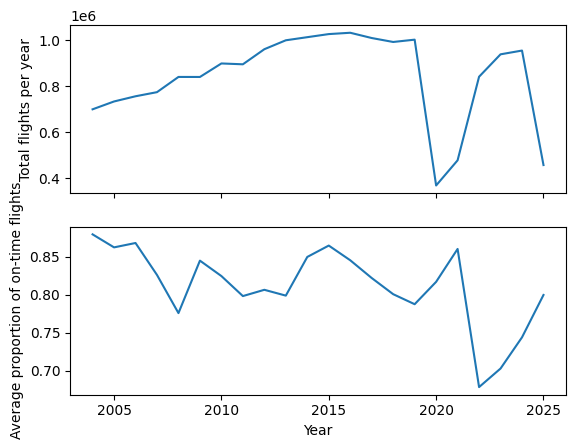

In [63]:
yearly_total_flown = all_airlines.groupby("Year")["Sectors_Flown"].sum().reset_index()

ave_on_time = (all_airlines.groupby("Year")["Departures_On_Time"].sum().reset_index()['Departures_On_Time']
              + all_airlines.groupby("Year")["Arrivals_On_Time"].sum().reset_index()['Arrivals_On_Time']) / (2 * yearly_total_flown['Sectors_Flown'])

fig, axes = plt.subplots(nrows=2, sharex=True)

axes[0].plot(yearly_total_flown['Year'], yearly_total_flown['Sectors_Flown'])
axes[1].plot(yearly_total_flown['Year'], ave_on_time)

axes[0].set(ylabel='Total flights per year')
axes[1].set(ylabel='Average proportion of on-time flights', xlabel='Year')

In [68]:
routes = flights['Route'].value_counts()[:21]
city_pairs = []
city_pairs_counts = []

for i in range(1, len(routes), 2):
    city_pairs.append(routes.index[i])
    city_pairs_counts.append(routes[i] + routes[i+1])

C:\Users\ryanw\AppData\Local\Temp\ipykernel_3652\2054920816.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  city_pairs_counts.append(routes[i] + routes[i+1])


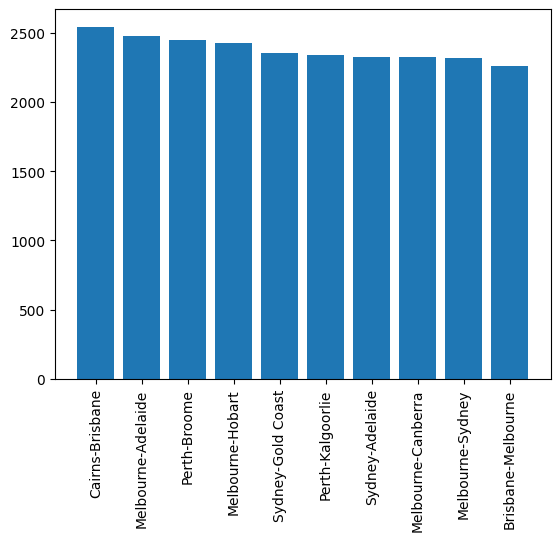

In [69]:
fig, ax = plt.subplots()

ax.bar(city_pairs, city_pairs_counts)
ax.tick_params(axis='x', rotation=90)